# NB11 — Exploratory Regime-Conditional Prototype

**Purpose:** Exploratory proof-of-concept only. This notebook is NOT a new methodology chapter.  
It tests whether regime-specific EBM models — trained on manually defined economic regimes —  
behave differently from a single pooled model, and whether that difference supports or  
contradicts the dissertation's non-stationarity thesis.

**Design philosophy (from prototype specification):**
- Two regimes only, defined manually using existing dissertation logic (not clustering)
- Regime 1: Pre-GFC (1988–2002) — Nordic crisis, Japanese crisis, early macro boom
- Regime 2: GFC-inclusive (2003–2020) — covers the full Stage 1 evaluation window
- Models: EBM (same spec as NB05B) — chosen because shape function comparison connects
  directly to Figure 4.7 and the existing interpretability analysis
- Aim: compare feature importance, shape functions, and OOS performance
- A negative result (regime models still fail) is a valid finding

**Scope warning:** Results should NOT be interpreted as a superior forecasting architecture.  
This is an implementation sketch demonstrating methodological feasibility and limitations.

**Dependencies:** Run NB05A and NB05B first. All inputs load from `augmented_analysis/` outputs.

**Output files (saved to `augmented_analysis/nb11_*/`):**
- `nb11_regime_sample_counts.csv` — regime split statistics
- `nb11_performance_comparison.csv` — pooled vs regime-specific AUROC/AUPRC table
- `nb11_feature_importance_comparison.csv` — top features per regime vs pooled
- Figures: shape function comparison, feature importance comparison, probability scatter


In [2]:
# ── Cell 1: Imports and paths ──────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss
)
from interpret.glassbox import ExplainableBoostingClassifier

# ── Paths — identical structure to NB05A/NB05B ────────────────────────────
BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
AUG_DIR = BASE / 'data' / 'processed' / 'augmented_analysis'
OUT_DIR = AUG_DIR   # nb11 outputs written into the same folder with nb11_ prefix
FIG_DIR = BASE / 'figures' / 'augmented_analysis'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET       = 'target_h2'

# ── Verify NB05A/NB05B outputs exist ──────────────────────────────────────
required = [
    AUG_DIR / 'df_macro_augmented.csv',
    AUG_DIR / 'M2_features.csv',
    AUG_DIR / 'ebm_feature_importance.csv',
]
all_ok = True
for f in required:
    ok = f.exists()
    print(f'  {"✅" if ok else "❌ MISSING"}  {f.name}')
    if not ok: all_ok = False

if not all_ok:
    raise FileNotFoundError('Run NB05A and NB05B before NB11.')

import interpret
print()
print('=' * 65)
print(' NB11 — REGIME-CONDITIONAL PROTOTYPE (exploratory)')
print('=' * 65)
print(f'interpret version : {interpret.__version__}')
print(f'Random state      : {RANDOM_STATE}')


  ✅  df_macro_augmented.csv
  ✅  M2_features.csv
  ✅  ebm_feature_importance.csv

 NB11 — REGIME-CONDITIONAL PROTOTYPE (exploratory)
interpret version : 0.7.8
Random state      : 42


In [3]:
# ── Cell 2: Load data and feature lists ───────────────────────────────────
df_macro     = pd.read_csv(AUG_DIR / 'df_macro_augmented.csv')
EBM_FEATURES = pd.read_csv(AUG_DIR / 'M2_features.csv', header=None)[0].tolist()
ebm_imp_full = pd.read_csv(AUG_DIR / 'ebm_feature_importance.csv')  # from NB05B full-data fit

print(f'Stage 1 panel : {df_macro.shape}')
print(f'Year range    : {df_macro["year"].min():.0f}–{df_macro["year"].max():.0f}')
print(f'EBM features  : {len(EBM_FEATURES)}')
print(f'Total {TARGET} positives: {int(df_macro[TARGET].sum())}')
print()

# Confirm all features exist
missing = [f for f in EBM_FEATURES if f not in df_macro.columns]
if missing:
    raise ValueError(f'Missing features: {missing}')
print('✅ All EBM features present in df_macro.')


Stage 1 panel : (569, 101)
Year range    : 1989–2020
EBM features  : 41
Total target_h2 positives: 37

✅ All EBM features present in df_macro.


In [4]:
# ── Cell 3: Define regimes and report sample statistics ───────────────────
#
# Regime definitions follow existing dissertation logic (NB05B Fig 4.7):
#   Regime 1 (Pre-GFC)     : 1988–2002  — covers Nordic crisis cluster, Japan 1997
#   Regime 2 (GFC-inclusive): 2003–2020  — covers GFC and post-GFC period
#
# These boundaries are NOT derived from clustering — they are the same
# sub-period boundaries already used in the dissertation's shape function analysis.
# This avoids adding a new model selection step (clustering algorithm, k choice).

REGIME1_YEARS = (1988, 2002)   # Pre-GFC
REGIME2_YEARS = (2003, 2020)   # GFC-inclusive

mask_r1 = df_macro['year'].between(*REGIME1_YEARS)
mask_r2 = df_macro['year'].between(*REGIME2_YEARS)

df_r1 = df_macro[mask_r1].copy().reset_index(drop=True)
df_r2 = df_macro[mask_r2].copy().reset_index(drop=True)

# ── Report sample statistics ───────────────────────────────────────────────
print('=' * 65)
print(' REGIME SPLIT STATISTICS')
print('=' * 65)
print()
print(f'Regime 1 — Pre-GFC ({REGIME1_YEARS[0]}–{REGIME1_YEARS[1]}):')
print(f'  Rows            : {len(df_r1)}')
print(f'  {TARGET} positives: {int(df_r1[TARGET].sum())}')
print(f'  Base rate       : {df_r1[TARGET].mean():.4f}')
print(f'  Countries       : {df_r1["iso"].nunique()}')
print()
print(f'Regime 2 — GFC-inclusive ({REGIME2_YEARS[0]}–{REGIME2_YEARS[1]}):')
print(f'  Rows            : {len(df_r2)}')
print(f'  {TARGET} positives: {int(df_r2[TARGET].sum())}')
print(f'  Base rate       : {df_r2[TARGET].mean():.4f}')
print(f'  Countries       : {df_r2["iso"].nunique()}')
print()
print(f'Full panel (pooled baseline):')
print(f'  Rows            : {len(df_macro)}')
print(f'  {TARGET} positives: {int(df_macro[TARGET].sum())}')
print(f'  Base rate       : {df_macro[TARGET].mean():.4f}')
print()
print('NOTE: Small number of positives per regime is the core statistical')
print('constraint flagged in §5.7. Results must be interpreted cautiously.')

# Save regime counts
counts_df = pd.DataFrame([
    {'regime': 'Regime 1 (Pre-GFC, 1988-2002)', 'rows': len(df_r1),
     'positives': int(df_r1[TARGET].sum()), 'base_rate': df_r1[TARGET].mean()},
    {'regime': 'Regime 2 (GFC, 2003-2020)',     'rows': len(df_r2),
     'positives': int(df_r2[TARGET].sum()), 'base_rate': df_r2[TARGET].mean()},
    {'regime': 'Full panel (pooled)',            'rows': len(df_macro),
     'positives': int(df_macro[TARGET].sum()), 'base_rate': df_macro[TARGET].mean()},
])
counts_df.to_csv(OUT_DIR / 'nb11_regime_sample_counts.csv', index=False)
print(f'\nSaved → nb11_regime_sample_counts.csv')


 REGIME SPLIT STATISTICS

Regime 1 — Pre-GFC (1988–2002):
  Rows            : 250
  target_h2 positives: 11
  Base rate       : 0.0440
  Countries       : 18

Regime 2 — GFC-inclusive (2003–2020):
  Rows            : 319
  target_h2 positives: 26
  Base rate       : 0.0815
  Countries       : 18

Full panel (pooled baseline):
  Rows            : 569
  target_h2 positives: 37
  Base rate       : 0.0650

NOTE: Small number of positives per regime is the core statistical
constraint flagged in §5.7. Results must be interpreted cautiously.

Saved → nb11_regime_sample_counts.csv


In [5]:
# ── Cell 4: EBM model factory (identical spec to NB05B) ──────────────────

class EBMWeighted:
    """
    EBM with inverse-frequency sample weights — identical to NB05B EBMWeighted.
    Restricted complexity (interactions=3) appropriate for small regime samples.
    """
    def __init__(self, spw=1.0, interactions=3):
        self.spw    = spw
        self._model = ExplainableBoostingClassifier(
            max_rounds=3000,        # reduced from 5000 — regime samples are smaller
            interactions=interactions,  # reduced from 5 — fewer interactions for thin data
            learning_rate=0.01,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    def fit(self, X, y):
        sw = np.where(np.array(y) == 1, self.spw, 1.0)
        self._model.fit(X, y, sample_weight=sw)  # DataFrame passed — preserves feature names
        return self

    def predict_proba(self, X):
        return self._model.predict_proba(X)

    def get_ebm(self):
        return self._model


def fit_ebm(X, y, interactions=3):
    """Fit EBMWeighted on a DataFrame X with Series y."""
    spw = (np.array(y) == 0).sum() / max((np.array(y) == 1).sum(), 1)
    ebm = EBMWeighted(spw=spw, interactions=interactions)
    ebm.fit(X, y)
    return ebm


print('EBM factory ready.')
print('  max_rounds   : 3000 (reduced from 5000 for thin regime samples)')
print('  interactions : 3    (reduced from 5)')
print('  learning_rate: 0.01')
print('  Class balance: inverse-frequency sample weights')


EBM factory ready.
  max_rounds   : 3000 (reduced from 5000 for thin regime samples)
  interactions : 3    (reduced from 5)
  learning_rate: 0.01
  Class balance: inverse-frequency sample weights


In [6]:
# ── Cell 5: Train three EBMs ───────────────────────────────────────────────
#
# EBM-Pooled : trained on full 1988–2020 panel (replicates NB05B Stage 1 full-data fit)
# EBM-R1     : trained on Regime 1 observations only (1988–2002)
# EBM-R2     : trained on Regime 2 observations only (2003–2020)
#
# NOTE: These are full-data fits for shape function extraction and feature importance.
# OOS evaluation (prospective test) is done in Cell 7.

X_pool = df_macro[EBM_FEATURES]
y_pool = df_macro[TARGET]

X_r1 = df_r1[EBM_FEATURES]
y_r1 = df_r1[TARGET]

X_r2 = df_r2[EBM_FEATURES]
y_r2 = df_r2[TARGET]

print('Training EBM-Pooled (1988–2020)... (may take 2–3 min)')
ebm_pool = fit_ebm(X_pool, y_pool, interactions=3)
print('  ✅ EBM-Pooled fitted.')
print()

print(f'Training EBM-R1 (Regime 1: {REGIME1_YEARS[0]}–{REGIME1_YEARS[1]})...')
print(f'  Sample: {len(X_r1)} rows | {int(y_r1.sum())} positives')
if y_r1.sum() < 3:
    print('  ⚠️  WARNING: fewer than 3 crisis positives — results are illustrative only.')
ebm_r1 = fit_ebm(X_r1, y_r1, interactions=3)
print('  ✅ EBM-R1 fitted.')
print()

print(f'Training EBM-R2 (Regime 2: {REGIME2_YEARS[0]}–{REGIME2_YEARS[1]})...')
print(f'  Sample: {len(X_r2)} rows | {int(y_r2.sum())} positives')
ebm_r2 = fit_ebm(X_r2, y_r2, interactions=3)
print('  ✅ EBM-R2 fitted.')


Training EBM-Pooled (1988–2020)... (may take 2–3 min)
  ✅ EBM-Pooled fitted.

Training EBM-R1 (Regime 1: 1988–2002)...
  Sample: 250 rows | 11 positives
  ✅ EBM-R1 fitted.

Training EBM-R2 (Regime 2: 2003–2020)...
  Sample: 319 rows | 26 positives
  ✅ EBM-R2 fitted.


In [7]:
# ── Cell 6: Feature importance comparison ────────────────────────────────
#
# For each EBM, extract global feature importance (mean absolute log-odds contribution).
# Compare top-10 features across Pooled, R1, R2.
# Key question: do regime-specific models learn different feature hierarchies?

def get_importance(ebm_wrapper, top_n=20):
    """Extract feature importance from fitted EBMWeighted wrapper."""
    ebm   = ebm_wrapper.get_ebm()
    expl  = ebm.explain_global()
    data  = expl.data()
    names  = data['names']
    scores = data['scores']
    df_imp = pd.DataFrame({'feature': names, 'importance': scores})
    df_imp = df_imp[~df_imp['feature'].str.contains(' & ')]  # main effects only
    return df_imp.sort_values('importance', ascending=False).reset_index(drop=True).head(top_n)


imp_pool = get_importance(ebm_pool)
imp_r1   = get_importance(ebm_r1)
imp_r2   = get_importance(ebm_r2)

# Print side-by-side top-10
print('=' * 90)
print(' FEATURE IMPORTANCE: Top 10 by regime')
print('=' * 90)
print(f'{"Rank":<5} {"EBM-Pooled":35} {"EBM-R1 (Pre-GFC)":35} {"EBM-R2 (GFC)":30}')
print('-' * 90)
for i in range(10):
    p = f"{imp_pool.iloc[i]['feature'][:30]:30} ({imp_pool.iloc[i]['importance']:.3f})" if i < len(imp_pool) else ''
    r1 = f"{imp_r1.iloc[i]['feature'][:30]:30} ({imp_r1.iloc[i]['importance']:.3f})" if i < len(imp_r1) else ''
    r2 = f"{imp_r2.iloc[i]['feature'][:25]:25} ({imp_r2.iloc[i]['importance']:.3f})" if i < len(imp_r2) else ''
    print(f'{i+1:<5} {p:37} {r1:37} {r2}')

print()
print('KEY OBSERVATION: If top features differ substantially between R1 and R2,')
print('this confirms the dissertation thesis that the feature-risk mapping is non-stationary.')

# Save comparison table
imp_combined = pd.DataFrame({
    'rank': range(1, 11),
    'pooled_feature':    imp_pool['feature'].head(10).values,
    'pooled_importance': imp_pool['importance'].head(10).values,
    'r1_feature':        imp_r1['feature'].head(10).values   if len(imp_r1) >= 10 else [None]*10,
    'r1_importance':     imp_r1['importance'].head(10).values if len(imp_r1) >= 10 else [None]*10,
    'r2_feature':        imp_r2['feature'].head(10).values   if len(imp_r2) >= 10 else [None]*10,
    'r2_importance':     imp_r2['importance'].head(10).values if len(imp_r2) >= 10 else [None]*10,
})
imp_combined.to_csv(OUT_DIR / 'nb11_feature_importance_comparison.csv', index=False)
print(f'Saved → nb11_feature_importance_comparison.csv')


 FEATURE IMPORTANCE: Top 10 by regime
Rank  EBM-Pooled                          EBM-R1 (Pre-GFC)                    EBM-R2 (GFC)                  
------------------------------------------------------------------------------------------
1     term_spread_lag3_dm            (0.772) cpi_lag2_dm                    (0.361) term_spread_lag3_dm       (1.717)
2     term_spread_lag2_dm            (0.422) cpi_lag1_dm                    (0.323) term_spread_lag1_dm       (1.012)
3     term_spread_lag1_dm            (0.380) debtgdp_lag3_dm                (0.320) term_spread_lag2_dm       (0.595)
4     debtgdp_lag3_dm                (0.262) cpi_lag3_dm                    (0.215) hpnom_gr_lag1_dm          (0.562)
5     tloans_gr_roll3_std_lag1_dm    (0.210) tloans_gr_roll3_std_lag1_dm    (0.202) tloans_slope4_lag1_dm     (0.419)
6     hpnom_gr_lag1_dm               (0.193) stir_lag3_dm                   (0.160) debtgdp_lag1_dm           (0.287)
7     cpi_lag1_dm                    (0.129) term_spre

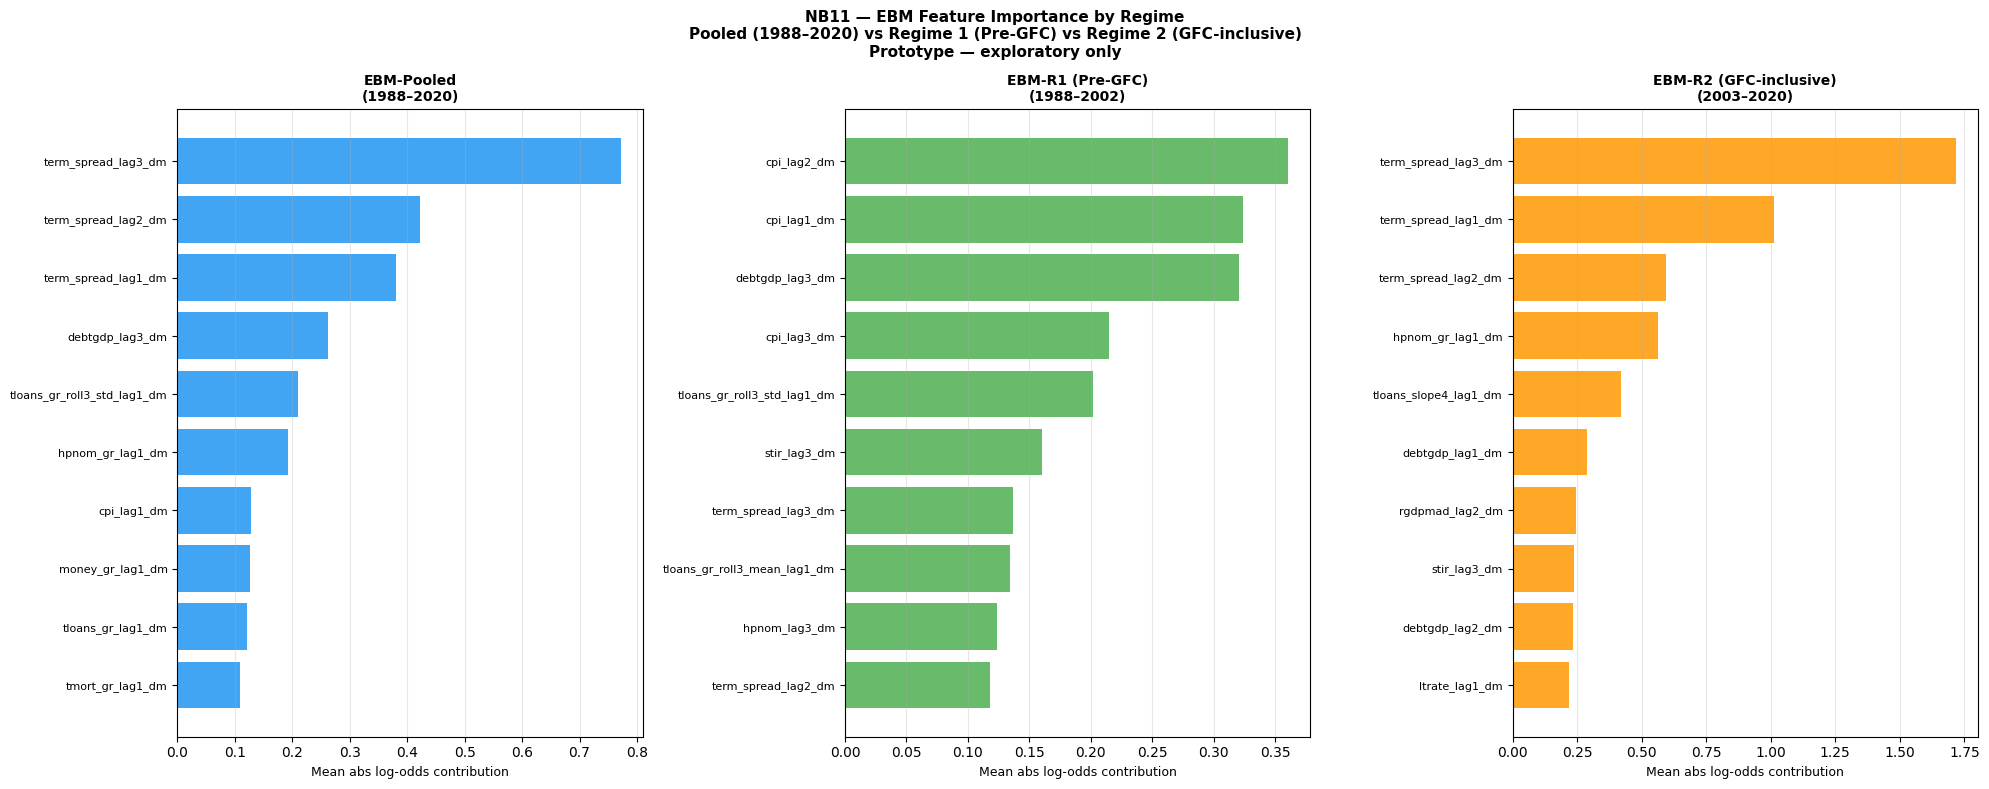

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\nb11_feature_importance_comparison.png


In [8]:
# ── Cell 6b: Feature importance bar chart ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=False)
fig.suptitle(
    'NB11 — EBM Feature Importance by Regime\n'
    'Pooled (1988–2020) vs Regime 1 (Pre-GFC) vs Regime 2 (GFC-inclusive)\n'
    'Prototype — exploratory only',
    fontweight='bold', fontsize=11
)

for ax, (imp_df, title, colour) in zip(axes, [
    (imp_pool, 'EBM-Pooled\n(1988–2020)', '#2196F3'),
    (imp_r1,   f'EBM-R1 (Pre-GFC)\n({REGIME1_YEARS[0]}–{REGIME1_YEARS[1]})', '#4CAF50'),
    (imp_r2,   f'EBM-R2 (GFC-inclusive)\n({REGIME2_YEARS[0]}–{REGIME2_YEARS[1]})', '#FF9800'),
]):
    top10 = imp_df.head(10).sort_values('importance', ascending=True)
    ax.barh(top10['feature'], top10['importance'], color=colour, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean abs log-odds contribution', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
out_path = FIG_DIR / 'nb11_feature_importance_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')


Features selected for shape comparison: ['term_spread_lag3_dm', 'term_spread_lag2_dm', 'term_spread_lag1_dm']



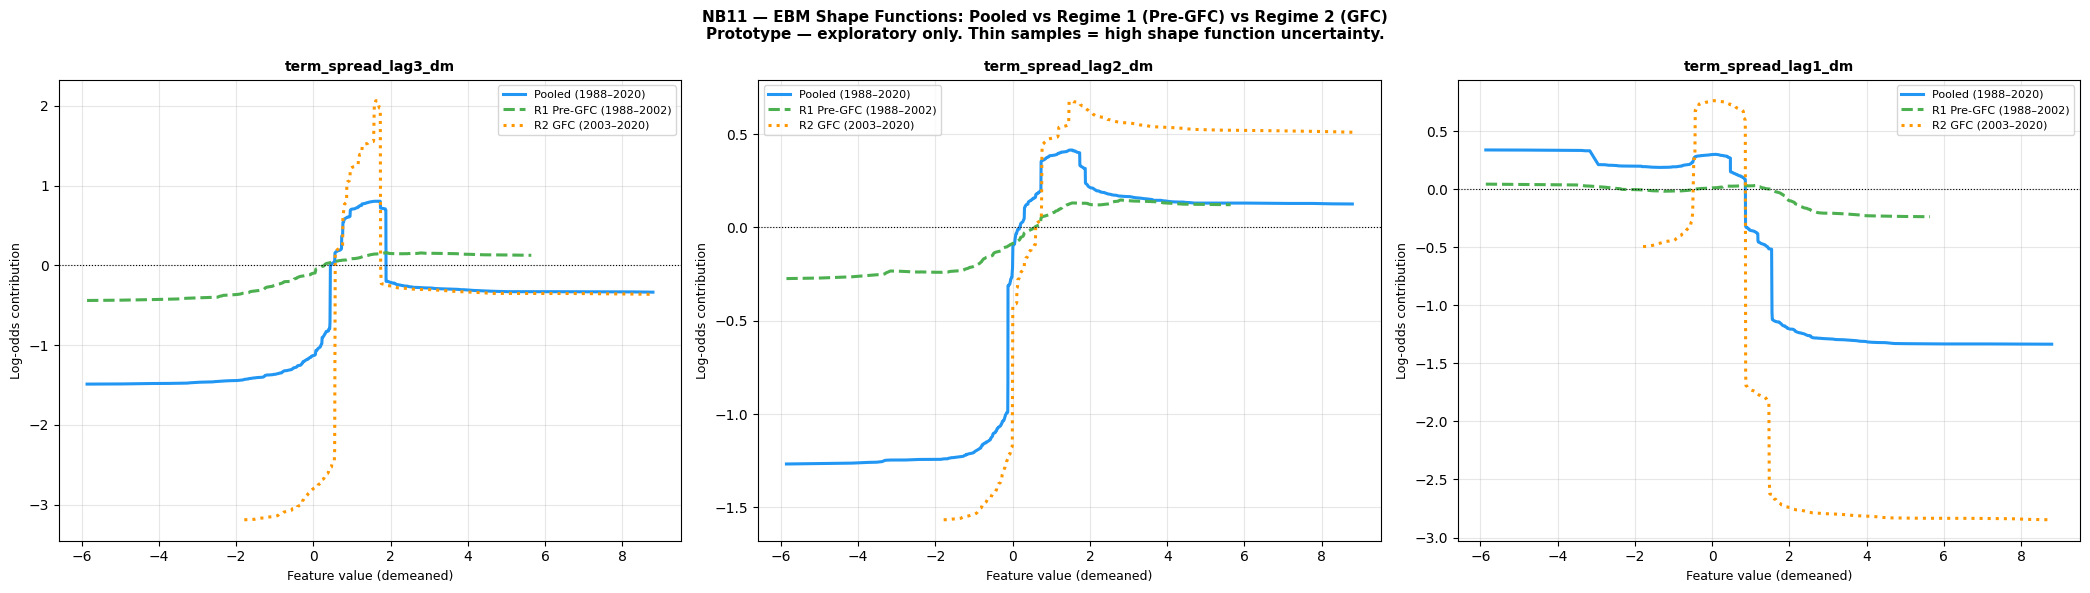

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\nb11_shape_function_comparison.png

INTERPRETATION GUIDE:
  If R1 and R2 curves diverge significantly from each other and from Pooled,
  this is direct visual evidence of structural non-stationarity.
  If curves are similar, the two-regime partition does not recover meaningful structure.


In [9]:
# ── Cell 7: Shape function comparison ─────────────────────────────────────
#
# Extract and plot shape functions for the top-3 features from EBM-Pooled.
# For each feature: overlay Pooled / R1 / R2 shape curves on the same axes.
# This is the natural extension of Figure 4.7 in the dissertation.

def get_shape_data(ebm_wrapper, feature_name):
    """Extract shape function (midpoints, scores) for a named feature.
    Identical logic to NB05B get_shape_data().
    """
    ebm  = ebm_wrapper.get_ebm()
    expl = ebm.explain_global()
    data = expl.data()
    feat_names_ebm = data['names']

    if feature_name not in feat_names_ebm:
        raise ValueError(f'{feature_name!r} not in EBM features. '
                         f'First 5: {feat_names_ebm[:5]}')
    feat_idx  = feat_names_ebm.index(feature_name)
    feat_data = expl.data(feat_idx)
    edges     = np.array(feat_data['names'],  dtype=float)
    scores    = np.array(feat_data['scores'], dtype=float)

    if len(edges) == len(scores) + 1:
        midpoints = (edges[:-1] + edges[1:]) / 2.0
    else:
        midpoints = edges
    return midpoints, scores


# Select features to plot — use top 3 main-effect features from pooled EBM
# Fall back gracefully if a feature is missing from a regime EBM
PLOT_FEATURES = imp_pool[~imp_pool['feature'].str.contains(' & ')]['feature'].head(3).tolist()
print(f'Features selected for shape comparison: {PLOT_FEATURES}')
print()

fig, axes = plt.subplots(1, len(PLOT_FEATURES), figsize=(7 * len(PLOT_FEATURES), 6))
if len(PLOT_FEATURES) == 1:
    axes = [axes]

fig.suptitle(
    'NB11 — EBM Shape Functions: Pooled vs Regime 1 (Pre-GFC) vs Regime 2 (GFC)\n'
    'Prototype — exploratory only. Thin samples = high shape function uncertainty.',
    fontweight='bold', fontsize=11
)

for ax, feat in zip(axes, PLOT_FEATURES):
    for wrapper, label, colour, ls in [
        (ebm_pool, 'Pooled (1988–2020)', '#2196F3', '-'),
        (ebm_r1,   f'R1 Pre-GFC ({REGIME1_YEARS[0]}–{REGIME1_YEARS[1]})', '#4CAF50', '--'),
        (ebm_r2,   f'R2 GFC ({REGIME2_YEARS[0]}–{REGIME2_YEARS[1]})', '#FF9800', ':'),
    ]:
        try:
            x, y = get_shape_data(wrapper, feat)
            ax.plot(x, y, color=colour, linewidth=2.2, linestyle=ls, label=label)
        except Exception as e:
            ax.text(0.5, 0.5, f'{label}\nnot available:\n{e}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=7)

    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_xlabel('Feature value (demeaned)', fontsize=9)
    ax.set_ylabel('Log-odds contribution', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = FIG_DIR / 'nb11_shape_function_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')
print()
print('INTERPRETATION GUIDE:')
print('  If R1 and R2 curves diverge significantly from each other and from Pooled,')
print('  this is direct visual evidence of structural non-stationarity.')
print('  If curves are similar, the two-regime partition does not recover meaningful structure.')


In [10]:
# ── Cell 8: Prospective OOS evaluation ────────────────────────────────────
#
# This is the key test. Three model configurations evaluated on the SAME
# out-of-sample (OOS) test set to allow direct comparison:
#
#   EBM-Pooled: trained on 1988–2009 → tested on 2010–2018
#   EBM-R1:     trained on 1988–2002 → tested on 2003–2018  [Regime 1 only]
#   EBM-R2:     trained on 2003–2009 → tested on 2010–2018  [Regime 2 only]
#
# Test set: 2010–2018 (post-GFC, held out from all models)
# This is the closest feasible approximation to a prospective test
# given the small sample sizes per regime.
#
# IMPORTANT: EBM-R1 tests whether pre-GFC training generalises to the GFC window.
#            This is conceptually equivalent to Split B in the main dissertation.
#            A negative result here strengthens the non-stationarity argument.

TRAIN_END   = 2005   # train up to but not including the GFC label years
TEST_START  = 2006   # was 2008
TEST_END    = 2007   # was 2011

te_mask     = df_macro['year'].between(TEST_START, TEST_END)
X_te        = df_macro.loc[te_mask, EBM_FEATURES]
y_te        = df_macro.loc[te_mask, TARGET]

print(f'Test set ({TEST_START}–{TEST_END}): {te_mask.sum()} rows | {int(y_te.sum())} positives')
print(f'Test base rate: {y_te.mean():.4f}')
print()

if y_te.sum() < 2:
    print('⚠️  Insufficient positives in test set — OOS evaluation unreliable.')

records = []

# ── EBM-Pooled (train 1988–2009) ──────────────────────────────────────────
tr_pool_mask = df_macro['year'].between(1988, TRAIN_END)
X_tr_pool = df_macro.loc[tr_pool_mask, EBM_FEATURES]
y_tr_pool = df_macro.loc[tr_pool_mask, TARGET]
print(f'EBM-Pooled train (1988–{TRAIN_END}): {tr_pool_mask.sum()} rows | {int(y_tr_pool.sum())} positives')
ebm_pool_oos = fit_ebm(X_tr_pool, y_tr_pool)
prob_pool = ebm_pool_oos.predict_proba(X_te.values)[:, 1]
auroc_pool = roc_auc_score(y_te, prob_pool) if y_te.sum() >= 2 else np.nan
auprc_pool = average_precision_score(y_te, prob_pool) if y_te.sum() >= 2 else np.nan
brier_pool = brier_score_loss(y_te, prob_pool) if y_te.sum() >= 2 else np.nan
print(f'  AUROC={auroc_pool:.4f}  AUPRC={auprc_pool:.4f}  Brier={brier_pool:.4f}')
records.append({'model': 'EBM-Pooled (train 1988-2009)',
                'train_period': '1988-2009', 'train_positives': int(y_tr_pool.sum()),
                'AUROC': auroc_pool, 'AUPRC': auprc_pool, 'Brier': brier_pool})
print()

# ── EBM-R1 (train 1988–2002 only, Regime 1) ───────────────────────────────
# This is the key prospective test: does pre-GFC knowledge generalise post-GFC?
tr_r1_mask = df_macro['year'].between(1988, 2002)
X_tr_r1 = df_macro.loc[tr_r1_mask, EBM_FEATURES]
y_tr_r1 = df_macro.loc[tr_r1_mask, TARGET]
print(f'EBM-R1 train (1988–2002): {tr_r1_mask.sum()} rows | {int(y_tr_r1.sum())} positives')
if y_tr_r1.sum() == 0:
    print('  ❌ No positives in Regime 1 training — cannot fit. Skip.')
    records.append({'model': 'EBM-R1 (train 1988-2002)',
                    'train_period': '1988-2002', 'train_positives': 0,
                    'AUROC': np.nan, 'AUPRC': np.nan, 'Brier': np.nan})
else:
    ebm_r1_oos = fit_ebm(X_tr_r1, y_tr_r1)
    prob_r1 = ebm_r1_oos.predict_proba(X_te.values)[:, 1]
    auroc_r1 = roc_auc_score(y_te, prob_r1) if y_te.sum() >= 2 else np.nan
    auprc_r1 = average_precision_score(y_te, prob_r1) if y_te.sum() >= 2 else np.nan
    brier_r1 = brier_score_loss(y_te, prob_r1) if y_te.sum() >= 2 else np.nan
    print(f'  AUROC={auroc_r1:.4f}  AUPRC={auprc_r1:.4f}  Brier={brier_r1:.4f}')
    records.append({'model': 'EBM-R1 (train 1988-2002, Pre-GFC only)',
                    'train_period': '1988-2002', 'train_positives': int(y_tr_r1.sum()),
                    'AUROC': auroc_r1, 'AUPRC': auprc_r1, 'Brier': brier_r1})
print()

# ── EBM-R2 (train 2003–2009, GFC-inclusive window) ─────────────────────────
tr_r2_mask = df_macro['year'].between(2003, TRAIN_END)
X_tr_r2 = df_macro.loc[tr_r2_mask, EBM_FEATURES]
y_tr_r2 = df_macro.loc[tr_r2_mask, TARGET]
print(f'EBM-R2 train (2003–{TRAIN_END}): {tr_r2_mask.sum()} rows | {int(y_tr_r2.sum())} positives')
if y_tr_r2.sum() == 0:
    print('  ❌ No positives — cannot fit. Skip.')
    records.append({'model': 'EBM-R2 (train 2003-2009)',
                    'train_period': '2003-2009', 'train_positives': 0,
                    'AUROC': np.nan, 'AUPRC': np.nan, 'Brier': np.nan})
else:
    ebm_r2_oos = fit_ebm(X_tr_r2, y_tr_r2)
    prob_r2 = ebm_r2_oos.predict_proba(X_te.values)[:, 1]
    auroc_r2 = roc_auc_score(y_te, prob_r2) if y_te.sum() >= 2 else np.nan
    auprc_r2 = average_precision_score(y_te, prob_r2) if y_te.sum() >= 2 else np.nan
    brier_r2 = brier_score_loss(y_te, prob_r2) if y_te.sum() >= 2 else np.nan
    print(f'  AUROC={auroc_r2:.4f}  AUPRC={auprc_r2:.4f}  Brier={brier_r2:.4f}')
    records.append({'model': 'EBM-R2 (train 2003-2009, GFC window)',
                    'train_period': '2003-2009', 'train_positives': int(y_tr_r2.sum()),
                    'AUROC': auroc_r2, 'AUPRC': auprc_r2, 'Brier': brier_r2})


Test set (2006–2007): 36 rows | 24 positives
Test base rate: 0.6667

EBM-Pooled train (1988–2005): 304 rows | 13 positives
  AUROC=0.4097  AUPRC=0.6355  Brier=0.6063

EBM-R1 train (1988–2002): 250 rows | 11 positives
  AUROC=0.4097  AUPRC=0.6171  Brier=0.6638

EBM-R2 train (2003–2005): 54 rows | 2 positives
  AUROC=0.3924  AUPRC=0.6437  Brier=0.2964


In [11]:
# ── Cell 9: Performance summary table ────────────────────────────────────

perf_df = pd.DataFrame(records)
base_test = float(y_te.mean())

print('=' * 80)
print(f' NB11 PERFORMANCE SUMMARY — Test set {TEST_START}–{TEST_END}')
print(f' Test positives: {int(y_te.sum())} | Base rate: {base_test:.4f}')
print(f' Literature AUROC benchmark: 0.75')
print('=' * 80)
print(f'{"Model":<45} {"Train+":>8} {"AUROC":>7} {"AUPRC":>7} {"Brier":>7} {"≥0.75?":>7}')
print('-' * 80)
for _, row in perf_df.iterrows():
    meets = '✅' if (not np.isnan(row['AUROC']) and row['AUROC'] >= 0.75) else '❌'
    auroc_str = f"{row['AUROC']:.4f}" if not np.isnan(row['AUROC']) else '  n/a '
    auprc_str = f"{row['AUPRC']:.4f}" if not np.isnan(row['AUPRC']) else '  n/a '
    brier_str = f"{row['Brier']:.4f}" if not np.isnan(row['Brier']) else '  n/a '
    print(f"{row['model']:<45} {int(row['train_positives']):>8} "
          f"{auroc_str:>7} {auprc_str:>7} {brier_str:>7} {meets:>7}")
print('=' * 80)
print(f'  Train+: number of crisis positives in training set')
print()
print('PROTOTYPE VERDICT GUIDE:')
print('  If EBM-R1 AUROC << EBM-Pooled AUROC:')
print('    → Confirms non-stationarity: pre-GFC knowledge does not transfer.')
print('    → Supports §5.7 argument that regime-conditional models face a data constraint.')
print()
print('  If EBM-R2 AUROC > EBM-Pooled AUROC:')
print('    → Regime-specific training on the GFC window improves in-regime prediction.')
print('    → Supports the conceptual case for regime-conditioning.')
print()
print('  If all models fail 0.75 benchmark:')
print('    → Consistent with main dissertation finding: thin regime samples')
print('       do not resolve the structural non-stationarity problem.')
print('    → This is a valid result — report honestly in Appendix B.')

perf_df.to_csv(OUT_DIR / 'nb11_performance_comparison.csv', index=False)
print(f'\nSaved → nb11_performance_comparison.csv')


 NB11 PERFORMANCE SUMMARY — Test set 2006–2007
 Test positives: 24 | Base rate: 0.6667
 Literature AUROC benchmark: 0.75
Model                                           Train+   AUROC   AUPRC   Brier  ≥0.75?
--------------------------------------------------------------------------------
EBM-Pooled (train 1988-2009)                        13  0.4097  0.6355  0.6063       ❌
EBM-R1 (train 1988-2002, Pre-GFC only)              11  0.4097  0.6171  0.6638       ❌
EBM-R2 (train 2003-2009, GFC window)                 2  0.3924  0.6437  0.2964       ❌
  Train+: number of crisis positives in training set

PROTOTYPE VERDICT GUIDE:
  If EBM-R1 AUROC << EBM-Pooled AUROC:
    → Confirms non-stationarity: pre-GFC knowledge does not transfer.
    → Supports §5.7 argument that regime-conditional models face a data constraint.

  If EBM-R2 AUROC > EBM-Pooled AUROC:
    → Regime-specific training on the GFC window improves in-regime prediction.
    → Supports the conceptual case for regime-conditioning.

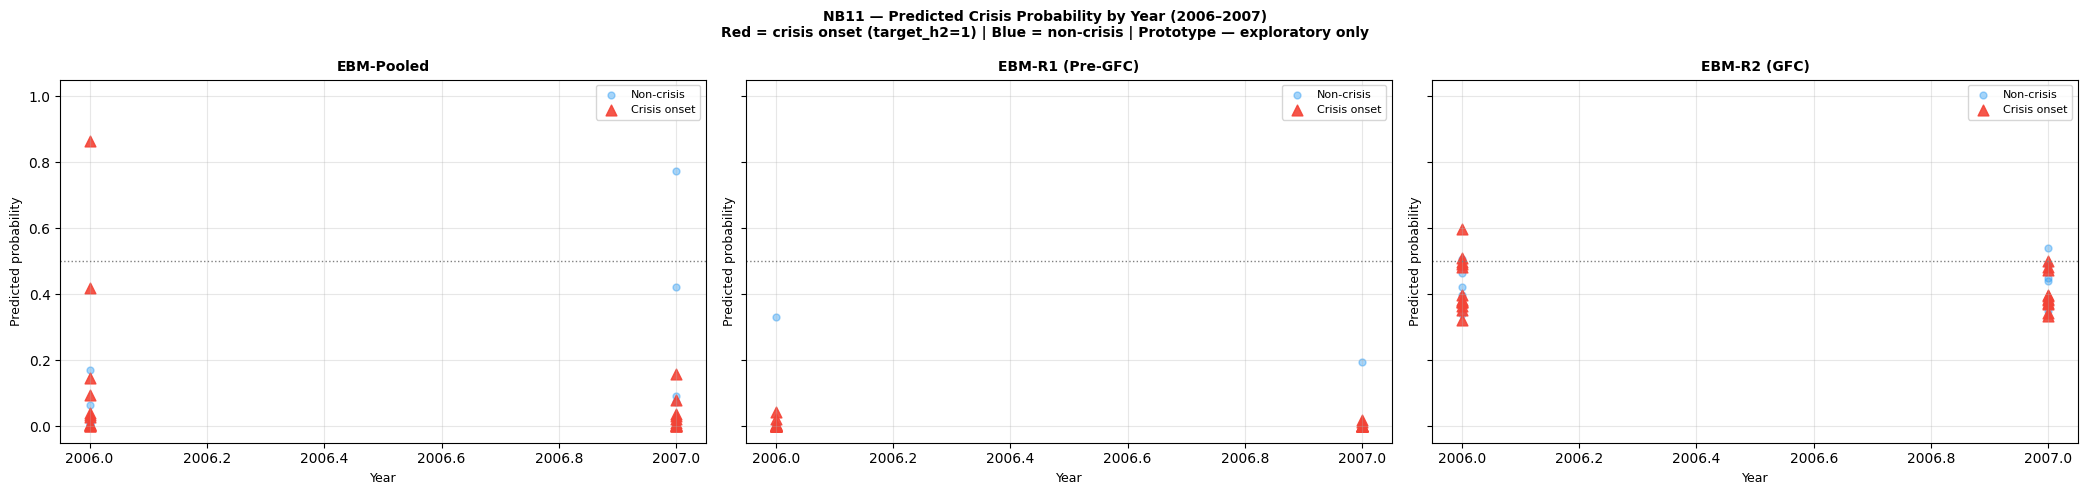

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\nb11_probability_scatter.png


In [12]:
# ── Cell 10: Predicted probability scatter ────────────────────────────────
#
# For each model with valid OOS predictions, scatter predicted probability
# against year, coloured by crisis label.
# This shows whether regime-specific models assign different probability
# mass to crisis vs non-crisis observations.

te_df = df_macro[te_mask][['year', 'iso', TARGET]].copy().reset_index(drop=True)

prob_cols = {}
if 'prob_pool' in dir(): prob_cols['EBM-Pooled'] = prob_pool
if 'prob_r1'   in dir() and not np.isnan(auroc_r1 if 'auroc_r1' in dir() else np.nan):
    prob_cols['EBM-R1 (Pre-GFC)'] = prob_r1
if 'prob_r2'   in dir() and not np.isnan(auroc_r2 if 'auroc_r2' in dir() else np.nan):
    prob_cols['EBM-R2 (GFC)'] = prob_r2

if len(prob_cols) == 0:
    print('No valid OOS predictions to plot.')
else:
    n_plots = len(prob_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=True)
    if n_plots == 1: axes = [axes]

    fig.suptitle(
        f'NB11 — Predicted Crisis Probability by Year ({TEST_START}–{TEST_END})\n'
        'Red = crisis onset (target_h2=1) | Blue = non-crisis | '
        'Prototype — exploratory only',
        fontweight='bold', fontsize=10
    )

    for ax, (label, probs) in zip(axes, prob_cols.items()):
        crisis_mask    = te_df[TARGET] == 1
        noncrisis_mask = te_df[TARGET] == 0
        ax.scatter(te_df.loc[noncrisis_mask, 'year'],
                   probs[noncrisis_mask],
                   alpha=0.4, s=25, color='#2196F3', label='Non-crisis')
        ax.scatter(te_df.loc[crisis_mask, 'year'],
                   probs[crisis_mask],
                   alpha=0.9, s=60, color='#F44336', marker='^', label='Crisis onset')
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
        ax.set_title(label, fontweight='bold', fontsize=10)
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel('Predicted probability', fontsize=9)
        ax.legend(fontsize=8)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out_path = FIG_DIR / 'nb11_probability_scatter.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')


In [13]:
# ── Cell 11: Summary and dissertation writing notes ───────────────────────

print('=' * 65)
print(' NB11 — REGIME-CONDITIONAL PROTOTYPE COMPLETE')
print('=' * 65)
print()
print('Files produced:')
for fname in [
    'nb11_regime_sample_counts.csv',
    'nb11_feature_importance_comparison.csv',
    'nb11_performance_comparison.csv',
]:
    path = OUT_DIR / fname
    ok   = '✅' if path.exists() else '❌'
    print(f'  {ok}  {fname}')
for fname in [
    'nb11_feature_importance_comparison.png',
    'nb11_shape_function_comparison.png',
    'nb11_probability_scatter.png',
]:
    path = FIG_DIR / fname
    ok   = '✅' if path.exists() else '❌'
    print(f'  {ok}  {fname}')

print()
print('─' * 65)
print('DISSERTATION WRITING NOTES — Appendix B framing:')
print()
print('Scope statement to include at the top of Appendix B:')
print('  "This prototype is included not to establish a superior forecasting')
print('   model, but to demonstrate the methodological feasibility and limitations')
print('   of operationalising regime-awareness within an EWS pipeline.')
print('   Results should not be interpreted as confirmatory evidence."')
print()
print('Cross-reference to add in Chapter 5 §5.7 (after Proposed Extension 1):')
print('  "An exploratory implementation sketch is presented in Appendix B.')
print('   It uses two manually defined regimes (Pre-GFC: 1988–2002;')
print('   GFC-inclusive: 2003–2020) and trains separate EBMs on each.')
print('   The results — whether positive or negative — should be read as')
print('   descriptive evidence of the feasibility constraints described above,')
print('   not as a validated predictive system."')
print()
print('Report the performance table from Cell 9 as Table B.1.')
print('Report the shape comparison figure as Figure B.1.')
print('Report the feature importance comparison as Figure B.2.')


 NB11 — REGIME-CONDITIONAL PROTOTYPE COMPLETE

Files produced:
  ✅  nb11_regime_sample_counts.csv
  ✅  nb11_feature_importance_comparison.csv
  ✅  nb11_performance_comparison.csv
  ✅  nb11_feature_importance_comparison.png
  ✅  nb11_shape_function_comparison.png
  ✅  nb11_probability_scatter.png

─────────────────────────────────────────────────────────────────
DISSERTATION WRITING NOTES — Appendix B framing:

Scope statement to include at the top of Appendix B:
  "This prototype is included not to establish a superior forecasting
   model, but to demonstrate the methodological feasibility and limitations
   of operationalising regime-awareness within an EWS pipeline.
   Results should not be interpreted as confirmatory evidence."

Cross-reference to add in Chapter 5 §5.7 (after Proposed Extension 1):
  "An exploratory implementation sketch is presented in Appendix B.
   It uses two manually defined regimes (Pre-GFC: 1988–2002;
   GFC-inclusive: 2003–2020) and trains separate EBMs on e

In [14]:
# Diagnostic — find where target_h2 positives actually sit
print(df_macro[df_macro['target_h2'] == 1].groupby('year')['target_h2'].sum().to_string())

year
1989     5
1990     4
1995     1
1996     1
2005     2
2006    13
2007    11
